Processing code for KPFM histograms with both single and multi-gaussian fitting and a stretched exponential fitting scatter plots for any time series. 
- Ensure any files are saved in chronological order
- Needs input of image time and skip rows (dependant on file saving format)
- All histograms need to be input as .txt files.
- Image time should be in seconds (take into account any potential error in image time i.e. for 85s use 90s).
- Tkinter used to select save files (if wanting to save as jpeg uncomment whichever graphs are needed.)
- Multi-gaussian fit is limited to 2 peaks per multi-gaussian
- FWHM is taken from largest peak of multiguassian

In [91]:
#Imports
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd
import scipy.stats as stats 
import matplotlib.colors as mcolors
import matplotlib.lines as mlines
import tkinter as tk
from tkinter import filedialog
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import ListedColormap
import matplotlib.cm as cm
from matplotlib.ticker import MaxNLocator
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
from tqdm import tqdm

Using Tkinter to open popup for folder path of histograms and for saving all plots to .jpeg files (can be changed if needed but other sections may need formatting) 

In [92]:
#Input directory and file saving function 
root = tk.Tk()
root.withdraw()
print("If pop up box not seen minimise spyder and select folder wanted for analysis")
folder_path = filedialog.askdirectory(title='Select input folder')
save_path = filedialog.askdirectory(title='Select Folder to Save Plot')

    
def save_plot_with_folder_dialog(fig, default_filename='plot.jpeg'):
    root = tk.Tk()
    root.withdraw()  # Hide the root window

    folder_path = filedialog.askdirectory(title='Select Folder to Save Plot')
    if not folder_path:
        print("Save cancelled.")
        return

    full_path = os.path.join(folder_path, default_filename)
    fig.savefig(full_path)
    print(f"Plot saved to: {full_path}")
    
def save_plot_to_folder(fig, folder_path, filename='plot.jpeg'):
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)  # Create the folder if it doesn't exist
    
    full_path = os.path.join(folder_path, filename)
    fig.tight_layout()
    fig.savefig(full_path, dpi=600, bbox_inches='tight')
    print(f"Plot saved to: {full_path}")

If pop up box not seen minimise spyder and select folder wanted for analysis


In [93]:
#Starting timer for runtime 
import time
start_time = time.time()

Using this section to set colourbars for histogram fitting. Change c1 and c2 as min and max colours (current is colourblind friendly). 

In [94]:
#Colourmap formatting
# Change c1 and c2 based on the min and max colours to be chosen 

def hex_to_RGB(hex_str):
    
    """ #FFFFFF -> [255,255,255]"""
    
    return [int(hex_str[i:i+2], 16) for i in range(1,6,2)]

def get_color_gradient(c1, c2, n):

    assert n > 1
    c1_rgb = np.array(hex_to_RGB(c1))/255
    c2_rgb = np.array(hex_to_RGB(c2))/255
    mix_pcts = [x/(n-1) for x in range(n)]
    rgb_colors = [((1-mix)*c1_rgb + (mix*c2_rgb)) for mix in mix_pcts]
    return ["#" + "".join([format(int(round(val*255)), "02x") for val in item]) for item in rgb_colors]


colors=[]
c1='#1A85FF'#deep blue
c2='#D41159' # deep pink


GB_U_color = "#5CBBFF"
GI_U_color = "#003357"
GB_P_color = "#D69AAB"
GI_P_color = "#8D1730"

Fitting for a single gaussian (not as accurate but sets a baseline for any changes that occur in the multi-gaussian fitting). 

In [95]:
#Single Gaussian Fitting function: 
def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

# Gaussian fitting function using data from a dataset (i.e. from each individual file) 
def fit_gaussian_from_dataset(x_data, y_data):
    """
    Fit a Gaussian curve to the provided dataset (x_data, y_data).
    Args:
    - x_data: Array-like, x values of the data
    - y_data: Array-like, y values of the data
    
    Returns:
    - A_fit: Amplitude of the fitted Gaussian
    - mu_fit: Mean (center) of the fitted Gaussian
    - sigma_fit: Standard deviation (width) of the fitted Gaussian
    - popt: Optimal parameters from curve fitting
    - pcov: Covariance matrix
    """
    # Initial guess for the parameters [A, mu, sigma]
    initial_guess = [max(y_data), np.mean(x_data), np.std(x_data)]

    try:
        # Fit the Gaussian curve to the data
        popt, pcov = curve_fit(gaussian, x_data, y_data, p0=initial_guess, maxfev=100000000)
        
        # Extract fitted parameters
        A_fit, mu_fit, sigma_fit = popt
        min_raw=np.min(x_data)
        mean_raw=np.mean(x_data)
        max_raw=np.max(x_data)
        # Print the fitted parameters for feedback
        #print(f"Fitted parameters:\nAmplitude: {A_fit}\nMean: {mu_fit}\nSigma: {sigma_fit}")
        #print(f"Raw data parameters are:\n Min = {min_raw}\n Mean = {mean_raw}\n Max = {max_raw}")
       
        # Return the fitted parameters and covariance matrix
        return A_fit, mu_fit, sigma_fit, popt, pcov, min_raw, mean_raw, max_raw

    except Exception as e:
        print(f"Error fitting Gaussian: {e}")
        return None, None, None, None, None

#Fitting for single gaussian
def fit_gaussian_from_files(file_directory, rows, image_time):
    min_scatter=[]
    mean_scatter=[]
    max_scatter=[]
    time_scatter=[]
    gaussian_scatter=[]
    t=-int(image_time)

    dpi_setting = 600
    figsize_x, figsize_y = (1147/dpi_setting), (770/dpi_setting)
    tick_length = 6
    legend_font = 12
    base_font_size = 12
    scatter_size = 18
    line_width = 3
    fig, ax = plt.subplots(1,1, sharey = True, figsize = (2.79,1.87))
    plt.rcParams.update({'font.size': base_font_size})
    ## this outputs a 1x1 subplot - change if you want more/less rows or columns ##
    ax = plt.gca()
    ax.tick_params(direction='in', length=tick_length)
    ax.tick_params(axis='both', labelsize=base_font_size)
    ax.margins (0.5,0.5)
    plt.xlabel("SPV (V)", size = base_font_size)
    ax.autoscale(enable=None, axis="x", tight=True)
    plt.ylabel("Distribution (V$^{-1}$)", fontsize=base_font_size)
    files=sorted([f for f in os.listdir(file_directory) if f.endswith('.txt')])
    n_files=len(files)
    colors=get_color_gradient(c1,c2,n_files)
    # Limit number of ticks
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))  # Max 5 ticks on x-axis
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))  # Max 5 ticks on y-axis
    # Loop through files in the specified directory
 #   for filename in os.listdir(file_directory):
    for idx, filename in enumerate(tqdm(files, desc="Processing files")):
        file_path = os.path.join(file_directory, filename)
        #print(f"\nProcessing file: {filename}")
        t += image_time
        time_scatter.append(t)

        with open(file_path, 'r', encoding='utf-8', errors='replace') as f:
            data = np.loadtxt(f, skiprows=rows)

        x_data = data[:, 0]
        y_data = data[:, 1]
            
            # Fit the Gaussian curve to this dataset
        A, mu, sigma, popt, pcov, min_raw, mean_raw, max_raw = fit_gaussian_from_dataset(x_data, y_data)
        min_scatter.append(min_raw)
        mean_scatter.append(mean_raw)
        max_scatter.append(max_raw)
        y_fit=gaussian(x_data,*popt)
        #for finding peak centre for fitted gaussian
        peak_index=np.argmax(y_fit)
        x_fit_max=x_data[peak_index]
        gaussian_scatter.append(x_fit_max)
        #Uncomment for debugging: 
        #print(f"Min:{min_scatter}\n Mean: {mean_scatter}\n Max: {max_scatter}")
        #print(time_scatter)
        # If fitting was successful, plot the result
        if A is not None:
            
            plt.scatter(x_data, y_data, label=f"{t}s", color=colors[idx], s=scatter_size)
            plt.plot(x_data, y_fit, label=f"_nolegend_", color=colors[idx], linewidth=line_width)
            plt.title(f"Single Gaussian Fitting", size=base_font_size)
            plt.xlabel("SPV (V)", size=20)
            plt.ylabel("Distribution $V^{-1}$", size=base_font_size)
            plt.autoscale()
            #plt.legend()
                
    print("All gaussians processed. Congrats!")
    # Add the colorbar after plotting
    cmap = LinearSegmentedColormap.from_list("custom_cmap", colors)
    norm = mcolors.Normalize(vmin=np.min(time_scatter), vmax=np.max(time_scatter))
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.tight_layout()
    cbar = fig.colorbar(sm, ax=ax, orientation='vertical')
    cbar.set_label('Time (s)', size=base_font_size)
    cbar.ax.tick_params(labelsize=base_font_size)
    plt.autoscale(enable=True, axis='y', tight=False)
    #Comment out if no file saving required
    fig=plt.gcf()
    save_plot_to_folder(fig, save_path, filename='SingleGaussian_Histogram.jpeg')
    return min_scatter, mean_scatter, max_scatter, time_scatter, gaussian_scatter
    plt.show() #Keep after saving figure due to errors. 

Multi-gaussian fitting function. Change estimate_guess_from_data --> wid =0.001 (based on current data) so change according to histogram width tolerance (either 0.1, 0.01 or 0.001). Runs through all files within folder. If initial time index is not 0 change this in the image time within function)

In [96]:
#Fitting for multi-gaussian
#Adjust peak width tolerance accordingly

# Function to model N Gaussians
def multi_gaussian(x, *params):
    n = len(params) // 3
    y = np.zeros_like(x)
    for i in range(n):
        amp = params[i * 3]
        cen = params[i * 3 + 1]
        wid = params[i * 3 + 2]
        y += amp * np.exp(-((x - cen) ** 2) / (2 * wid ** 2))
    return y


# Auto-generate initial guess based on data
def estimate_guess_from_data(x, y, prominence=0.1, distance=10):
    y_smooth = gaussian_filter1d(y, sigma=2)
    peaks, _ = find_peaks(y_smooth, prominence=prominence, distance=distance)
    
    # Sort peaks by height (amplitude) and limit to top 2
    if len(peaks) > 2:
        sorted_indices = np.argsort(properties['prominences'])[::-1][:2]
        peaks = peaks[sorted_indices]

    guess = []
    for i in peaks:
        amp = y[i]
        cen = x[i]
        wid = 0.001 # Adjust based on data
        guess += [amp, cen, wid]
    
    return guess, len(peaks)


#Multi-gaussian fitting for all files within file directory
def multi_gaussian_folder(file_directory, rows, image_time):
    min_scatter=[]
    mean_scatter=[]
    max_scatter=[]
    time_scatter=[]
    multigaussian_min = []
    multigaussian_max = []
    multigaussian_peak=[]
    t=-int(image_time)
    #Plotting parameters
    dpi_setting = 600
    figsize_x, figsize_y = (2227/dpi_setting), (1498/dpi_setting)
    tick_length = 6
    legend_font = 12
    base_font_size = 12
    scatter_size = 6
    line_width = 1.5
    fig, ax = plt.subplots(1, 1, sharey=True, figsize=(figsize_x, figsize_y))
    plt.rcParams.update({'font.size': base_font_size})
    ax = plt.gca()
    ax.tick_params(direction='in', length=tick_length)
    ax.tick_params(axis='both')
    ax.margins (0.5,0.5)
    plt.xlabel("SPV (V)")
    ax.autoscale(enable=None, axis="x", tight=True)
    plt.ylabel("Distribution (V$^{-1}$)")
    files=sorted([f for f in os.listdir(file_directory) if f.endswith('.txt')])
    n_files=len(files)
    colors=get_color_gradient(c1,c2,n_files)
    # Limit number of ticks
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))  # Max 5 ticks on x-axis
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))  # Max 5 ticks on y-axis
    results = []
    for idx, filename in enumerate(tqdm(files, desc="Processing files")):
    
        file_path = os.path.join(file_directory, filename)
        #print(f"\nProcessing file: {filename}") #Use if you want each individual file processed
        t += image_time
        time_scatter.append(t)

        with open(file_path, 'r', encoding='utf-8', errors='replace') as f:
            data = np.loadtxt(f, skiprows=rows)

        x_data = data[:, 0]
        y_data = data[:, 1]
            
        # Estimate initial guess and peak count
        initial_guess, n_peaks = estimate_guess_from_data(x_data, y_data)
        min_raw=np.min(x_data)
        max_raw=np.max(x_data)
        mean_raw=np.mean(x_data)
        min_scatter.append(min_raw)
        mean_scatter.append(mean_raw)
        max_scatter.append(max_raw)
        #x_fit= np.linspace(np.min(x_data), np.max(x_data), 1000000)
        popt, _ = curve_fit(multi_gaussian, x_data, y_data, p0=initial_guess, maxfev=100000000)
        y_fit=multi_gaussian(x_data,*popt)
        peak_index_max=np.argmax(y_fit)
        x_peak_centre=x_data[peak_index_max]
        multigaussian_peak.append(x_peak_centre)

        #For finding min and max *i.e. either side of the peaks. 
        # Extract Gaussian parameters
        gaussians = []
        for i in range(len(popt) // 3):
            amp = popt[i*3]
            cen = popt[i*3+1]
            wid = abs(popt[i*3+2])
            gaussians.append({'amp': amp, 'cen': cen, 'wid': wid})

        # Identify the highest peak
        #highest = max(gaussians, key=lambda g: g['amp'])
        highest = gaussians[np.argmax([g['amp'] for g in gaussians])]
        # FWHM = 2.355 * sigma
        fwhm = 2.355 * highest['wid']
        x_left = highest['cen'] - fwhm / 2
        x_right = highest['cen'] + fwhm / 2

        # Store in lists for output
        multigaussian_min.append(x_left)
        multigaussian_max.append(x_right)
        # Optional: print for debugging
        #print(f"  Highest Peak at x = {highest['cen']:.4f}")
        #print(f"  FWHM = {fwhm:.4f} → Bounds: [{x_left:.4f}, {x_right:.4f}]")
        if n_peaks is not None:
   
            # Plot
                #Plotting parameters
            plt.scatter(x_data, y_data, label=f"{t}s",color=colors[idx], s=scatter_size)
            plt.plot(x_data, multi_gaussian(x_data, *popt), label=f"_nolegend_", color=colors[idx],linewidth=line_width)
            plt.title(f"Multi-Gaussian Fitting")
            plt.xlabel("SPV(V)")
            plt.ylabel("Distribution $V^{-1}$")
            plt.autoscale()
        #plt.legend()
        #plt.tight_layout()
            #plt.show()
    print("All multi gaussians processed. Congrats!")

    # Add the colorbar after plotting
    cmap = LinearSegmentedColormap.from_list("custom_cmap", colors)
    norm = mcolors.Normalize(vmin=np.min(time_scatter), vmax=np.max(time_scatter))
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.tight_layout()
    cbar = fig.colorbar(sm, ax=ax, orientation='vertical')
    cbar.set_label('Time (s)')
    cbar.ax.tick_params(size=tick_length, labelsize = base_font_size)
    plt.autoscale(enable=True, axis='y', tight=False)
    #Uncomment for file saving
    fig=plt.gcf()
    save_plot_to_folder(fig,save_path,filename='MultiGaussian_Histogram.jpeg')
    return mean_scatter, time_scatter, multigaussian_min, multigaussian_max, multigaussian_peak
    plt.show()    

Set image time and number of rows to skip within .txt files. Call x and y data for scatter plots from either single or multi-gaussian and raw or fitted data. 

X:/ramadan_group/Group Members/Rehmat Goodwin/Lab Data/Processed Data/25_03_12_FACs_HK_Batch1/1 - KPFM/250506_RG0089_KPFM/Histograms/SPVLightOn


Processing files: 100%|██████████| 100/100 [00:04<00:00, 23.62it/s]


All multi gaussians processed. Congrats!
Plot saved to: X:/ramadan_group/Group Members/Rehmat Goodwin/Lab Data/Processed Data/25_03_12_FACs_HK_Batch1/FinalPaperFigures/Temporal SPV/Passivated/SPVOn_White\MultiGaussian_Histogram.jpeg


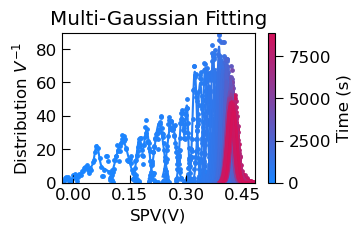

In [97]:
#Outputting single and multi gaussian plots:
#Uncomment folder_path input or copy into code directly if tkinter not working
#Can uncomment inputs if this varies between experiments
#folder_path=input("What is the folder path?")
#folder_path=r"X:\ramadan_group\Group Members\Rehmat Goodwin\Lab Data\Processed Data\25_03_12_FACs_HK_Batch1\250312_RG0087_KPFM\Histograms\CPD copy\LightOn" # Replace with your folder path
#rows=int(input("How many rows should be skipped?"))
rows=3
#image_time=int(input("What was the image time?(in seconds)"))
image_time= 90 #seconds
print(folder_path)
#min,mean,max,time, gaussian_scatter=fit_gaussian_from_files(folder_path,rows,image_time)

mean_scatter, time_scatter, multigaussian_min, multigaussian_max, multigaussian_peak= multi_gaussian_folder(folder_path, rows, image_time)

x_data=time_scatter #Change according to whether using single or multi gaussian
y_data=multigaussian_peak #can change this dependant on whether you want single or multi-gaussian 
#y_data = gaussian_scatter # Good check for if there is strange behaviour from the multi-gaussian fit. 


Plot saved to: X:/ramadan_group/Group Members/Rehmat Goodwin/Lab Data/Processed Data/25_03_12_FACs_HK_Batch1/FinalPaperFigures/Temporal SPV/Passivated/SPVOn_White\ScatterWithSpread.jpeg


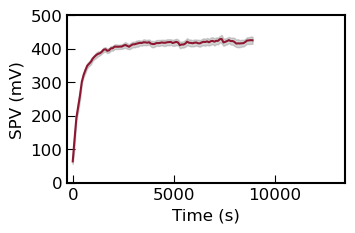

In [98]:
#Plotting scatter without fitting
#uncomment to check scatter for multiple different scatter plots. 

import numpy as np 
dpi_setting = 600
figsize_x, figsize_y = (2227/dpi_setting), (1498/dpi_setting)
tick_length = 6
legend_font = 12
base_font_size = 12
scatter_size = 18
line_width = 1.5


multigaussian_peak_new=[round(x*1000,4) if not np.isnan(x) else np.nan for x in multigaussian_peak]
multigaussian_min_new=[round(x*1000,4) if not np.isnan(x) else np.nan for x in multigaussian_min]
multigaussian_max_new=[round(x*1000,4) if not np.isnan(x) else np.nan for x in multigaussian_max]


plt.figure(figsize=(figsize_x, figsize_y))
ax = plt.gca()
plt.rcParams.update({'font.size': base_font_size})
ax.tick_params(axis='both',direction='in', length=tick_length)
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(line_width)
plt.xlabel("Time (s)")
plt.ylabel("SPV (mV)")
ax.xaxis.set_major_locator(MaxNLocator(nbins=3))
ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
plt.plot(time_scatter,multigaussian_peak_new,'-', label = 'Average SPV', color=GI_P_color, linewidth=line_width)
plt.plot(time_scatter, multigaussian_min_new, color='#6F6F6F', linewidth=0.0001)
plt.plot(time_scatter, multigaussian_max_new, color='#6F6F6F', linewidth=0.0001)
plt.fill_between(time_scatter, multigaussian_min_new, multigaussian_max_new, color='#6F6F6F',
                 alpha=0.3)
if np.max(time_scatter)> 9050:
    plt.vlines(x=image_time*100,
           ymin=0, 
           ymax=500,
           linestyle = '--',
           linewidth=1,
          color = 'black',
#          label = 'Light Off'
              )
    recovery = [image_time*100, image_time*150]
    plt.fill_between(recovery, 0, 500, color=GI_P_color, alpha=0.2)
#else:
#    print('Only single region of time series. No light off line needed')
ax.set_ylim(0,500)
ax.set_xlim(-image_time*3,image_time*150)
#uncomment for saving figures
fig=plt.gcf()
plt.tight_layout()
save_plot_to_folder(fig, save_path,filename='ScatterWithSpread.jpeg')
plt.show()


In [99]:
#Stretched exponential fitting function: 

#def stretched_exponential(x, A, tau, beta, const):
#    return  A * np.exp(-(x / tau) ** beta) + const

def stretched_exponential(x, A, tau, beta, const):
    # Avoid division by zero and negative roots
    x = np.array(x)
    with np.errstate(divide='ignore', invalid='ignore'):
        safe_vals = np.where(x > 0, (x / tau) ** beta, 0)
        y = A * np.exp(-safe_vals) + const
    return y

Adjusted exponential to check time constant and fitting if stretched exponential doesn't work. 

In [100]:
# Adjusted exponential fit to check: 

def adjusted_exponential(t, A, tau, const):
    return A*(1-np.exp(-(t/tau)))+const


In [101]:
#Testing logarithmic function 
#DO NOT NEED
def v_fit_func(rho, a, b, c):
    return (a + (-b * np.log(rho))**c)**(-1)

Completing stretched exponential and adjusted exponential fitting and plotting. Values output for guesses onto the plot in a textbox. 
can omit running this step if just aiming to output gaussian's. 

In [102]:
"""#Running through to try stretched exponential
#This can be made into a function if needed
#Stretched exponential fitting: 
try: 
    # Fit the data using curve_fit
    #defining initial guesses: 
    A_initial = np.max(y_data)#If data is positive then this should be max, if negative then it is min
    tau_initial= np.median(x_data) #Can also try max/2 or mean to see if this works
    beta_initial = 1 #any value between 0.5 and 1 but usually works fine as 0.5 or as 1. 
    const_initial=np.max(y_data)
    print(f"Constant initial = {const_initial:.2f}")
    initial_guess = [A_initial,tau_initial,beta_initial, const_initial]  # Initial guess for A, tau, beta
    params, covariance = curve_fit(stretched_exponential, x_data, y_data, p0=initial_guess, maxfev=1000000)
    #k_initial = 1/tau_initial
    # Extract the parameters (A, tau, beta)
    A, tau, beta, const = params
    print("Fitted Parameters:")
    print(f"A = {A:.2f}")
    print(f"tau = {tau:.2f}")
    print(f"beta = {beta:.2f}")
    print(f"constant={const:.2f}")


    # Generate 1000 new x values between the minimum and maximum of original x_data
    x_fit= np.linspace(np.min(x_data), np.max(x_data), 1000000)
    #y_fit= stretched_exponential(x_fit, *params)
    y_fit = np.array([stretched_exponential(np.array([x]), *params)[0] for x in tqdm(x_fit, desc="Fitting")])
    #y_initial = y_data[0]
    # Calculate 37% of the initial value (A)
    #y_37_percent = 1.37 * y_initial

    # Find the x-value where y reaches 37% of its initial value
    # We use np.abs to find the closest value in y_data to the target y_37_percent
    #closest_idx = np.argmin(np.abs(y_fit - y_37_percent))
    #x_at_37_percent = x_fit[closest_idx]

   # print(f"37% of initial CPD is: {y_37_percent:.2f}")
   # print(f"Time (x-value) when y reaches 37% of its initial value: {x_at_37_percent:.2f}")

    # Plotting data:
    plt.figure(figsize=(20, 12.5))
    plt.rcParams.update({'font.size': 48})
    ax = plt.gca()
    ax.tick_params(direction='in', length=10, width=4)
    ax.tick_params(axis='both')#, labelsize=48)
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(4)
    #ax.margins (0.3,0.3)
    plt.xlabel("Time (s)")#, fontsize =48)
    plt.ylabel("SPV (V)")#, fontsize=48)
    # Limit number of ticks
#    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))  # Max 5 ticks on x-axis if needed 
#    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))  # Max 5 ticks on y-axis if needed
    #plt.plot(x_data, y_data, label='Data', color='#8D1730', linewidth=2)
    plt.scatter(x_data, y_data, label='Transient SPV', color='#8D1730', s=100)
    plt.plot(x_fit, y_fit, label='Fitted SPV', color='#6F6F6F', linewidth=4)
    #plt.axhline(y=y_37_percent, color='green', linestyle='--', label="37% of Initial Value")
    #plt.title(f"Stretched Exponential Fitting", size=20)
    #Adding tau and other values to plot: 
    # add a textbox with fit parameters
    plt.legend(loc='lower right')#, fontsize = 40)
#    textbox_str = f"$\\tau$: {tau:.2f}s\nA: {A:.2f}\n$\\beta$: {beta:.2f}\nC: {const:.2f}"
#    ax.text(0.95, 0.3, textbox_str,
#    transform=ax.transAxes,
#    fontsize=14,
#    verticalalignment='top',
#    horizontalalignment='right',
#    bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))# Safely add a textbox with fit parameters
#    ax.set_ylim(0.05,0.45)
    #plt.autoscale(enable=True, axis='y', tight=False)
    #uncomment for saving figures
    #fig=plt.gcf()
    #save_plot_to_folder(fig, save_path,filename=f'StretchedExpFitScatter_beta_guess_{beta_initial:.1f}.jpeg')
    #Automatically adjust the y-axis
    
except Exception as e: 
    print("Fitting has failed. See errors or just come back later.")
    print(e.args)

#Fitted scatter plots
plt.show()
"""

'#Running through to try stretched exponential\n#This can be made into a function if needed\n#Stretched exponential fitting: \ntry: \n    # Fit the data using curve_fit\n    #defining initial guesses: \n    A_initial = np.max(y_data)#If data is positive then this should be max, if negative then it is min\n    tau_initial= np.median(x_data) #Can also try max/2 or mean to see if this works\n    beta_initial = 1 #any value between 0.5 and 1 but usually works fine as 0.5 or as 1. \n    const_initial=np.max(y_data)\n    print(f"Constant initial = {const_initial:.2f}")\n    initial_guess = [A_initial,tau_initial,beta_initial, const_initial]  # Initial guess for A, tau, beta\n    params, covariance = curve_fit(stretched_exponential, x_data, y_data, p0=initial_guess, maxfev=1000000)\n    #k_initial = 1/tau_initial\n    # Extract the parameters (A, tau, beta)\n    A, tau, beta, const = params\n    print("Fitted Parameters:")\n    print(f"A = {A:.2f}")\n    print(f"tau = {tau:.2f}")\n    print(f

Constant initial = 0.06
Fitted Parameters:
A = 0.34
tau = 468.38
constant=0.08


Fitting: 100%|██████████| 1000000/1000000 [00:03<00:00, 265768.27it/s]


8910
Plot saved to: X:/ramadan_group/Group Members/Rehmat Goodwin/Lab Data/Processed Data/25_03_12_FACs_HK_Batch1/FinalPaperFigures/Temporal SPV/Passivated/SPVOn_White\AdjustedExpFitScatter.jpeg


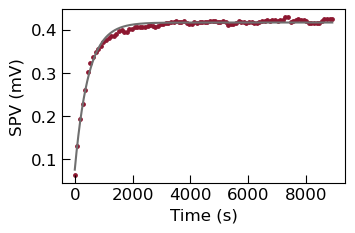

0.4169806891154634
0.39901565925976495


In [ ]:
#Running through to try adjusted exponential
#This can be made into a function if needed
#Adjusted exponential fitting: 
try: 
    # Fit the data using curve_fit
    #defining initial guesses: 
    A_initial = np.max(y_data)#If data is positive then this should be max, if negative then it is min
    tau_initial= np.median(x_data) #Can also try max/2 or mean to see if this works
    const_initial=np.min(y_data)
    print(f"Constant initial = {const_initial:.2f}")
    initial_guess = [A_initial,tau_initial, const_initial]  # Initial guess for A, tau, const
    params, covariance = curve_fit(adjusted_exponential, x_data, y_data, p0=initial_guess, maxfev=1000000)
    #k_initial = 1/tau_initial
    # Extract the parameters (A, tau, beta)
    A, tau, const = params
    print("Fitted Parameters:")
    print(f"A = {A:.2f}")
    print(f"tau = {tau:.2f}")
    print(f"constant={const:.2f}")


    # Generate 1000 new x values between the minimum and maximum of original x_data
    x_fit= np.linspace(np.min(x_data), np.max(x_data), 1000000)
    #y_fit= adjusted_exponential(x_fit, *params)
    y_fit = np.array([adjusted_exponential(np.array([x]), *params)[0] for x in tqdm(x_fit, desc="Fitting")])

    print(np.max(x_data))
#    y_initial = y_data[0]
    # Calculate 37% of the initial value (A)
 #   y_37_percent = 1.37 * y_initial
    
    # Find the x-value where y reaches 37% of its initial value
    # We use np.abs to find the closest value in y_data to the target y_37_percent
 #   closest_idx = np.argmin(np.abs(y_fit - y_37_percent))
 #  x_at_37_percent = x_fit[closest_idx]

   # print(f"37% of initial CPD is: {y_37_percent:.2f}")
   # print(f"Time (x-value) when y reaches 37% of its initial value: {x_at_37_percent:.2f}")
    
    # Plotting data:
    dpi_setting = 600
    figsize_x, figsize_y = (2227/dpi_setting), (1498/dpi_setting)
    tick_length = 6
    legend_font = 12
    base_font_size = 12
    scatter_size = 6
    line_width = 1.5
    plt.figure(figsize=(figsize_x, figsize_y))
    plt.rcParams.update({'font.size': base_font_size})
    ax = plt.gca()
    ax.tick_params(direction='in', length=tick_length)
    ax.tick_params(axis='both')
    #ax.margins (0.3,0.3)
    plt.xlabel("Time (s)")
    plt.ylabel("SPV (mV)")
    # Limit number of ticks

    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))  # Max 5 ticks on x-axis
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))  # Max 5 ticks on y-axis
    #plt.plot(x_data, y_data, label='Data', color='#8D1730', linewidth=2)
    plt.scatter(x_data, y_data, label='Data', color=GI_P_color, s=scatter_size)
    plt.plot(x_fit, y_fit, label='Fit', color='#6F6F6F', linewidth=line_width)
    #plt.axhline(y=y_37_percent, color='green', linestyle='--', label="37% of Initial Value")
    #plt.title(f"Adjusted Exponential Fitting", size=base_font_size)
    #Adding tau and other values to plot: 
    # Add a textbox with some information
    # Safely add a textbox with fit parameters

#    plt.legend(loc='upper left', fontsize = legend_font)
#    textbox_str = f"$\\tau$: {tau:.2f}s\nA: {A:.2f}\nC: {const:.2f}"
#    ax.text(0.95, 0.25, textbox_str,
#    transform=ax.transAxes,
#    fontsize=base_font_size,
#    verticalalignment='top',
#    horizontalalignment='right',
#    bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
#    textbox_str = f"$\\tau$: {tau:.2f}s\nA: {A:.2f}\nC: {const:.2f}"
#    ax.text(0.95, 0.95, textbox_str,
#        transform=ax.transAxes,
#        fontsize=14,
#        verticalalignment='top',
#        horizontalalignment='right',
#        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
    plt.autoscale(enable=True, axis='y', tight=False)
    #ax.set_ylim(-0.05,0.05)
    #uncomment for saving figures
    fig=plt.gcf()
    save_plot_to_folder(fig, save_path,filename='AdjustedExpFitScatter.jpeg')
    #Automatically adjust the y-axis
    
except Exception as e: 
    print("Fitting has failed. See errors or just come back later.")
    print(e.args)

#Fitted scatter plots
plt.show()
print(np.max(y_fit))
print(np.mean(y_fit[5:1000000]))

In [105]:
print(np.mean(y_fit[5:1000000]))

0.3990146878786215


In [104]:
#Runtime check: 
import time
end_time = time.time()
elapsed = end_time-start_time
print(f'Total runtime is {elapsed:.3f} seconds')

Total runtime is 9.725 seconds
